In [1]:
import json

from pandas import concat, DataFrame, isna, read_csv
from scipy.stats import entropy

In [ ]:
df_combined = read_csv("output/combined_report.csv")

# json_index = df_combined[~isna(df_combined["probabilities"])].index
# df_combined.loc[json_index, "probabilities"] = df_combined.loc[json_index]["probabilities"].apply(json.loads)
df_combined["probabilities"] = df_combined["probabilities"].apply(json.loads)

df_combined_metrics = read_csv("output/combined_report_with_metrics.csv")
df_combined_metrics["probabilities"] = df_combined_metrics["probabilities"].apply(
    json.loads
)

# Statistics/metrics

## Uniformity of probabilities

In [ ]:
records_new = []

# Skip scenarios for which already a record exists with metrics
for i in df_combined[
    ~df_combined["scenario_name"].isin(df_combined_metrics["scenario_name"].values)
].index:
    if not isinstance(df_combined.loc[i, "probabilities"], list):
        continue
    df_group = DataFrame(df_combined.loc[i, "probabilities"])

    n_targets = df_group["entity_target"].nunique()
    probabilities = df_group.groupby(["entity_source", "entity_target"])[
        "probability"
    ].sum()
    probabilities = probabilities.astype(float)

    kl_divergence = entropy(pk=probabilities.values, qk=[1 / n_targets] * n_targets)

    df_combined.loc[i, "kl_divergence"] = (
        kl_divergence  # closer to 0 is closer to uniform distribution
    )

    records_new.append(df_combined.loc[i].to_dict())

df_combined_metrics = concat([df_combined_metrics, DataFrame(records_new)]).reset_index(
    drop=True
)

### Number of merges

In [ ]:
df_combined_metrics["n_merges"] = df_combined_metrics["probabilities"].apply(
    lambda x: sum(r["n_merges"] for r in x)
)

### Uniformity of merges and splits

In [ ]:
def average_split_merge_kl(x):
    total = 0
    for r in x:
        if not r.get("split_merge_kl"):
            continue
        total += r["split_merge_kl"]

    return total / len(x)


df_combined_metrics["split_merge_kl"] = df_combined_metrics["probabilities"].apply(
    average_split_merge_kl
)

### Average number of resources (per production step)

In [ ]:
for scenario_name in df_combined_metrics["scenario_name"].unique():
    with open(f"{scenario_name}.json") as f:
        average_n_resources = (
            DataFrame(json.load(f)["production_resources"])
            .groupby("step")
            .size()
            .mean()
        )

    df_combined_metrics.loc[
        df_combined_metrics[
            df_combined_metrics["scenario_name"] == scenario_name
        ].index,
        "average_n_resources",
    ] = average_n_resources

### Average number of production steps executed before aggregations

In [ ]:
from numpy import mean

# Unpack lists and take calculate mean
df_combined_metrics["n_production_steps_aggregations"] = df_combined_metrics[
    "probabilities"
].apply(
    lambda x: mean(
        [i for r in x for l in r["n_production_steps_aggregations"] for i in l]
    )
)

In [ ]:
df_combined_metrics["probabilities"] = df_combined_metrics["probabilities"].apply(
    json.dumps
)
df_combined_metrics.to_csv("output/combined_report_with_metrics.csv", index=False)

# Visualize/process results

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

from pandas import concat, isna, read_csv, set_option
from scipy.stats import pearsonr

set_option("display.max_colwidth", None)

In [ ]:
df_combined_metrics = read_csv("output/combined_report_with_metrics.csv")

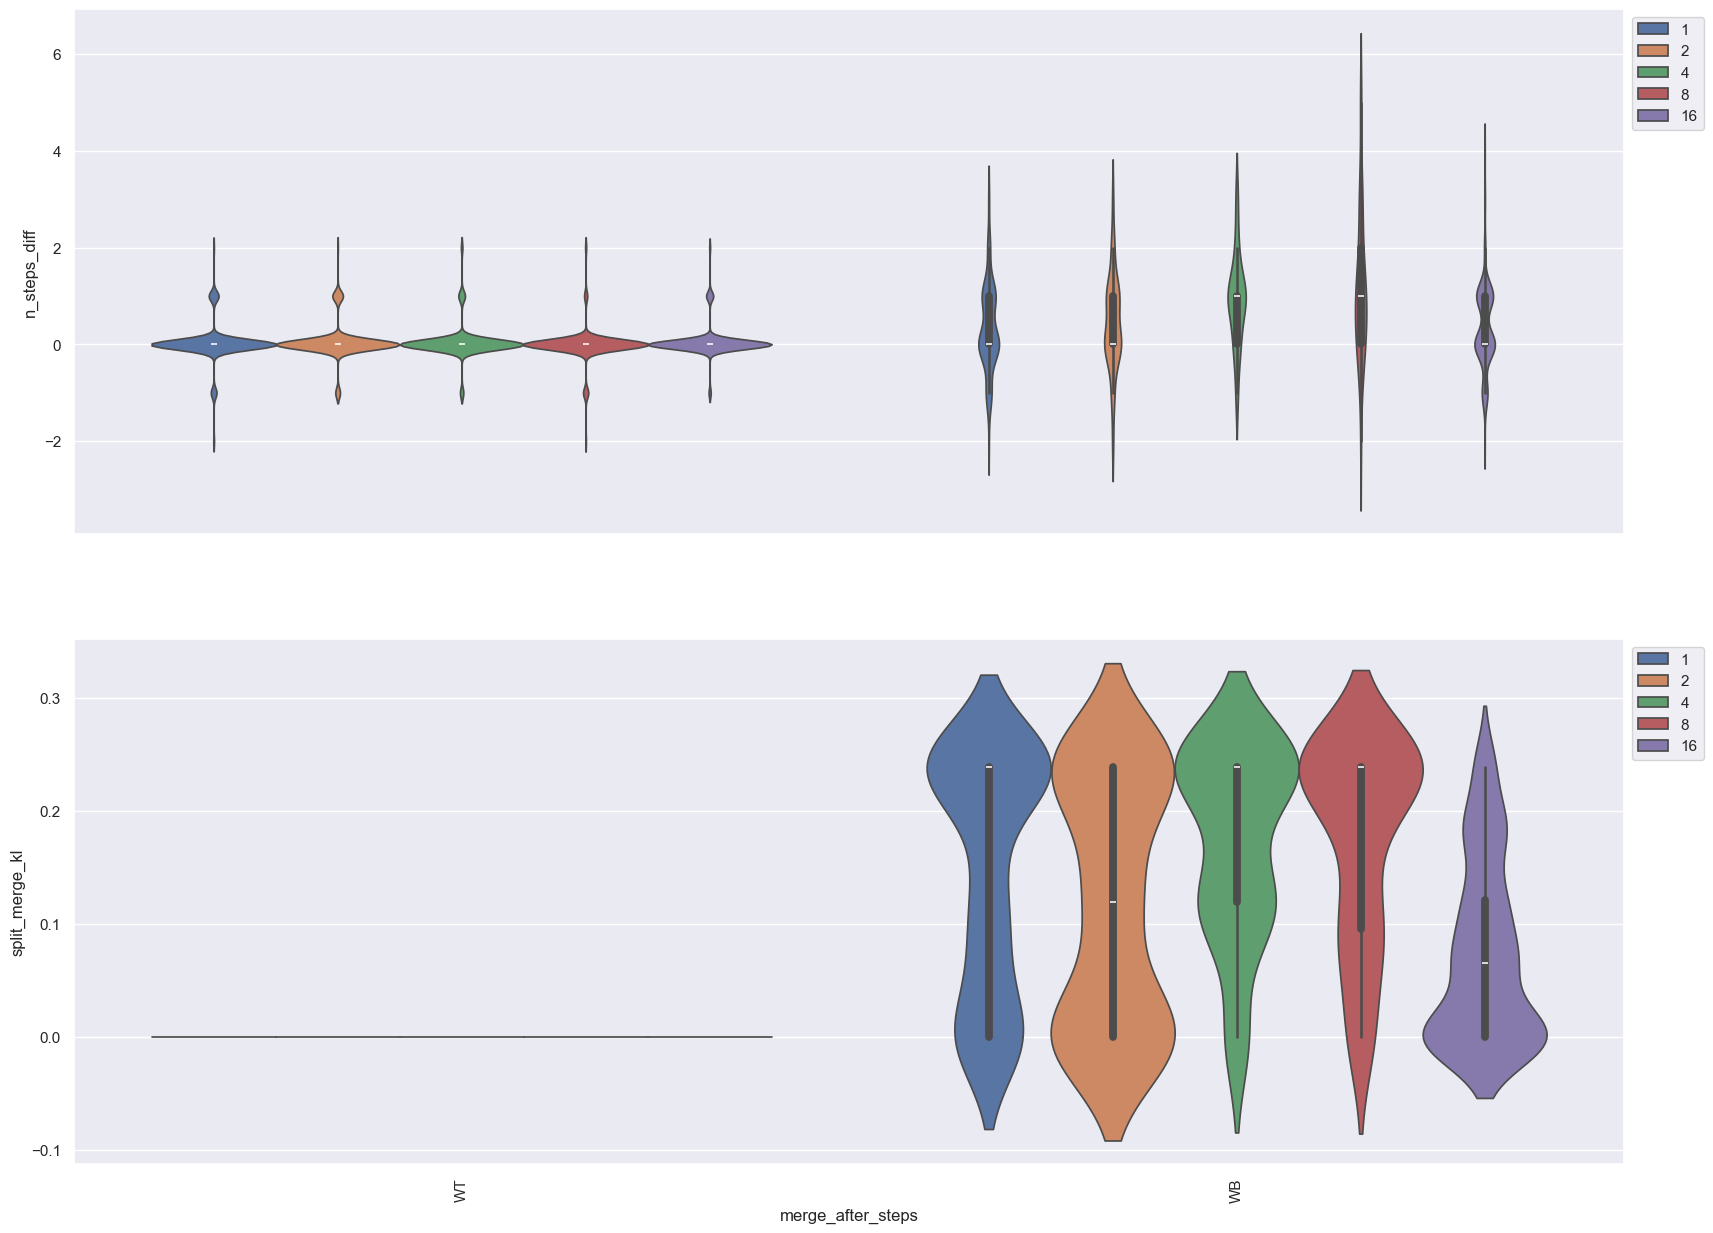

In [ ]:
filter_scenario = "merge_after_steps=W[TB]\+"  # "split_after_steps=Marking"
df_plot = df_combined_metrics[
    df_combined_metrics["scenario_name"].str.contains(filter_scenario)
].copy()
# df_plot = df_combined_metrics.copy()

x_label = "merge_after_steps"
y_labels = ["n_steps_diff", "split_merge_kl"]
df_plot[x_label] = df_plot["scenario_name"].str.extract(rf"{x_label}=([A-Za-z0-9-]+)")

fig, axes = plt.subplots(nrows=len(y_labels), sharex=True, figsize=(20, 15))
sns.set_theme(font_scale=1)

# group_label = "number_of_devices"
group_label = "n_resources_factor"
df_plot[group_label] = df_plot["scenario_name"].str.extract(
    rf"{group_label}=([A-Za-z0-9-]+)"
)

for i, y_label in enumerate(y_labels):
    ax = sns.violinplot(
        data=df_plot[~isna(df_plot["n_steps_diff"])],
        x=x_label,
        y=y_label,
        hue=group_label,
        ax=axes[i],
    )

    # ax.set_ylabel("$R$")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

# plt.grid()

plt.savefig(
    f"output/figures/violin_{'+'.join(y_labels)}_x={x_label}_group={group_label}.svg",
    bbox_inches="tight",
)

Text(value='merge_after_steps=W[TB]\\+', description='Filter Scenario:', layout=Layout(width='50%'))

Dropdown(description='X-axis Label:', options=('merge_after_steps', 'number_of_devices', 'n_resources_factor',…

SelectMultiple(description='Y-axis Label:', index=(6, 9), options=('file', 'product_model', 'probabilities', '…

Dropdown(description='Group Label:', index=3, options=('merge_after_steps', 'number_of_devices', 'n_resources_…

Button(description='Update Plot', style=ButtonStyle())

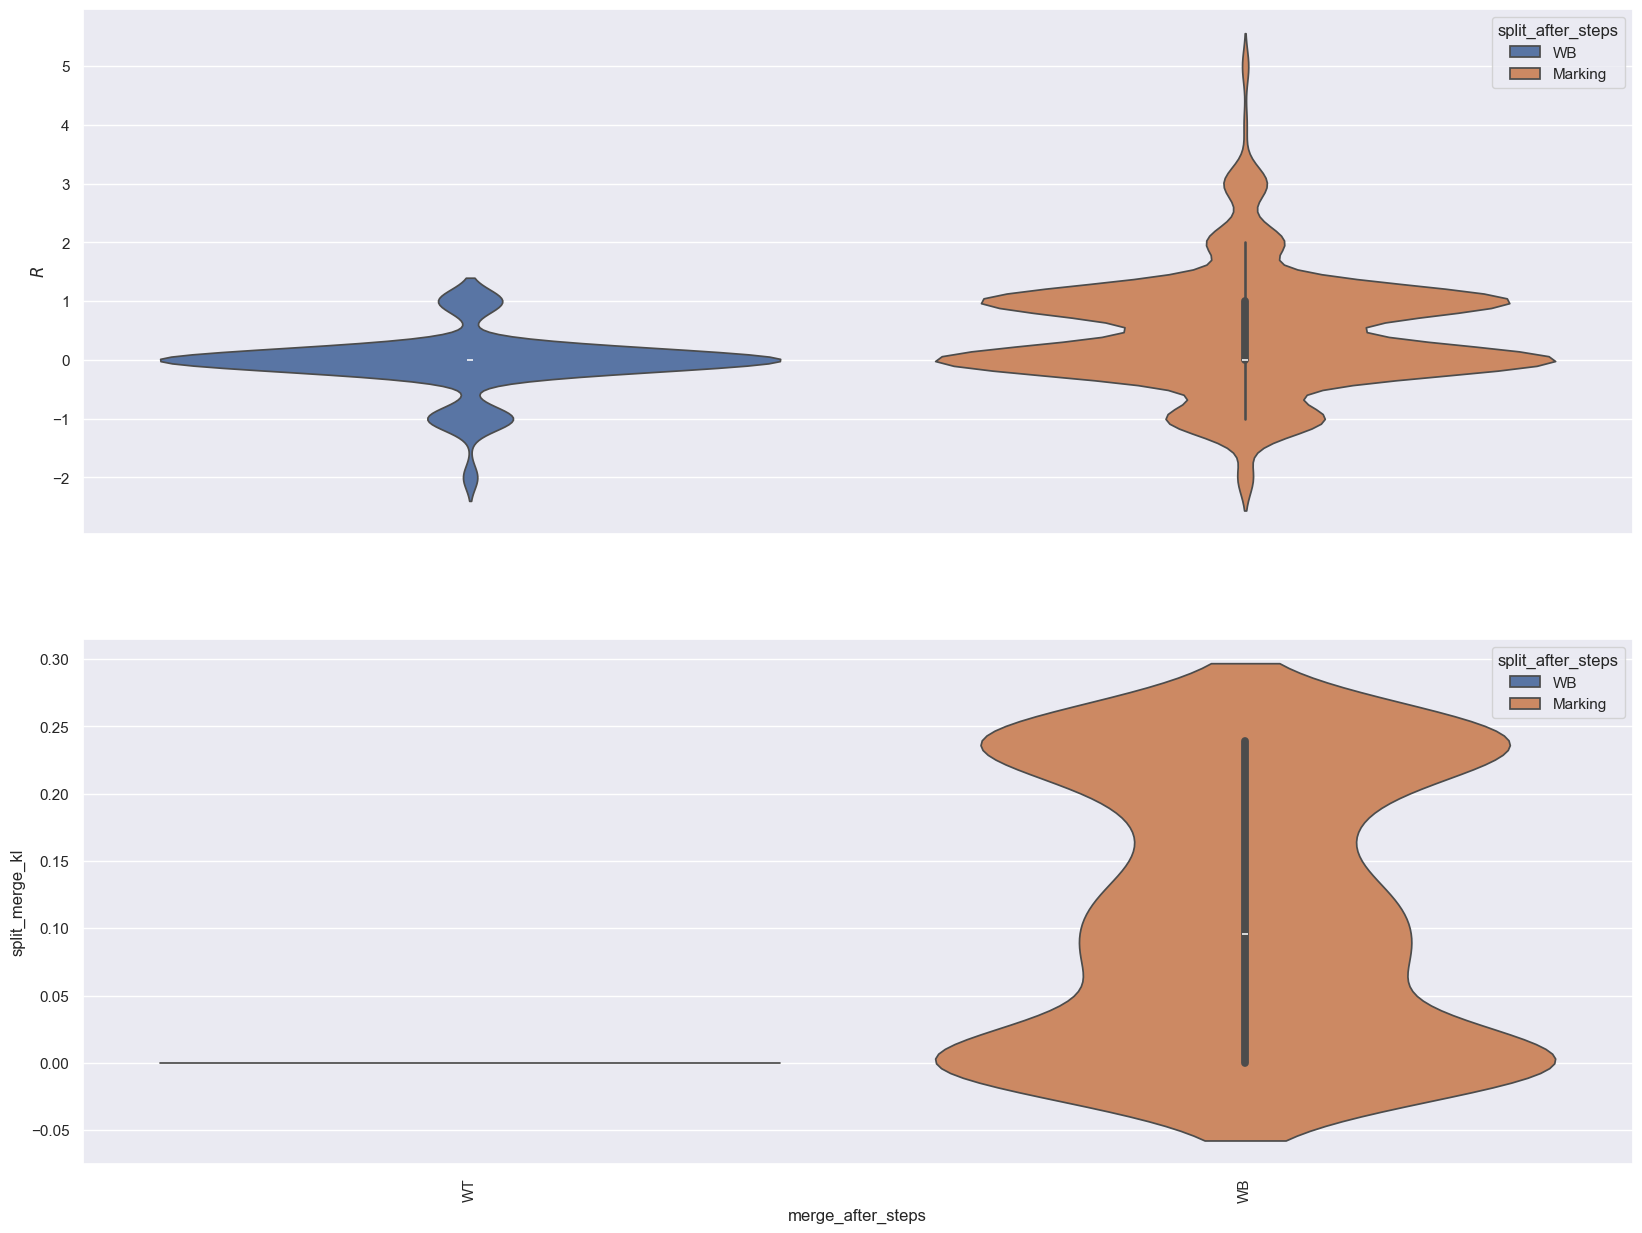

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

scenario_options = [
    "merge_after_steps",
    "number_of_devices",
    "n_resources_factor",
    "split_after_steps",
]

y_label_mapping = {
    "n_steps_diff": "$R$",
}

# Define interactive widgets
filter_scenario_widget = widgets.Text(
    value=filter_scenario,
    description="Filter Scenario:",
    layout=widgets.Layout(width="50%"),
)

x_label_widget = widgets.Dropdown(
    options=scenario_options,
    value="merge_after_steps",
    description="X-axis Label:",
)

y_labels_widget = widgets.SelectMultiple(
    options=df_combined_metrics.columns,
    value=["n_steps_diff", "split_merge_kl"],
    description="Y-axis Label:",
)

group_label_widget = widgets.Dropdown(
    options=scenario_options,
    value="merge_after_steps",
    description="Group Label:",
)


# Function to update the plot
def update_plot(filter_scenario, x_label, y_labels, group_label):
    clear_output(wait=True)
    display(
        filter_scenario_widget,
        x_label_widget,
        y_labels_widget,
        group_label_widget,
        plot_button,
    )

    df_plot = df_combined_metrics[
        df_combined_metrics["scenario_name"].str.contains(filter_scenario)
    ].copy()

    df_plot[x_label] = df_plot["scenario_name"].str.extract(
        rf"{x_label}=([A-Za-z0-9-]+)"
    )
    df_plot[group_label] = df_plot["scenario_name"].str.extract(
        rf"{group_label}=([A-Za-z0-9-]+)"
    )

    fig, axes = plt.subplots(nrows=len(y_labels), sharex=True, figsize=(20, 15))
    sns.set_theme(font_scale=1)

    for i, y_label in enumerate(y_labels):
        ax = sns.violinplot(
            data=df_plot[~isna(df_plot["n_steps_diff"])],
            x=x_label,
            y=y_label,
            hue=group_label,
            ax=axes[i],
            legend="full",
        )
        ax.tick_params(axis="x", rotation=90)
        ax.set_ylabel(y_label_mapping.get(y_label, y_label))

    plt.savefig(
        f"output/figures/violin_{'+'.join(y_labels)}_x={x_label}_group={group_label}.svg",
        bbox_inches="tight",
    )
    plt.show()


# Button to trigger the update
plot_button = widgets.Button(description="Update Plot")


# Event handler for the button
def on_button_click(b):
    update_plot(
        filter_scenario_widget.value,
        x_label_widget.value,
        y_labels_widget.value,
        group_label_widget.value,
    )


plot_button.on_click(on_button_click)

# Display widgets
display(
    filter_scenario_widget,
    x_label_widget,
    y_labels_widget,
    group_label_widget,
    plot_button,
)

In [ ]:
import os
import sys

from pathlib import Path

basepath = Path(
    r"C:\Users\s158699\Documents\PhD\Experiments\Simulation\aggregated_event_data"
)

sys.path.append(os.path.join(*basepath.parts))

from aggregated_traces.utils.construct_ekg import (
    check_quantities,
    generate_networkx_di_graph,
    insert_DF_DP,
    insert_fractions,
    load_rdf_graph,
)
from aggregated_traces.utils.ekg_analysis import (
    compute_aggregation_uniformity,
    compute_aggregation_average_kl_trace_graph,
    compute_trace_probabilities,
    compute_number_of_merges_in_trace_graph,
    compute_number_of_steps_at_aggregations,
)

In [ ]:
from aggregated_traces.utils.visualization import load_rdf_graph

visualize_ekg_graph_rdf = load_rdf_graph(
    basepath.joinpath(
        "logs/scenarios/merge_after_steps=+number_of_devices=50+n_resources_factor=1+split_after_steps=WT-DB-WB-Marking-FT/run_0.json"
    ),
    store="Oxigraph",
)

# Insert DF/DP relations
visualize_ekg_graph_rdf = insert_DF_DP(visualize_ekg_graph_rdf)

# Insert fractions on the relations
# visualize_ekg_graph_rdf = insert_fractions(visualize_ekg_graph_rdf)

# Create NetworkX graph
# visualize_ekg_graph_nx = generate_networkx_di_graph(visualize_ekg_graph_rdf)

# generate_graph_visualization(visualize_ekg_graph_nx, base_figure_path="output/check")